# Day 10 — Inventory Optimization
Reorder point, safety stock, and EOQ recommendations using forecasted demand per SKU.

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

process = Path('../Data/Processed')
figure  = Path('../Reports/Figure')
report  = Path('../Reports/Model_Reports')

# Config
LEAD_TIME_DAYS   = 7     # days from order to delivery
SERVICE_LEVEL    = 0.95  # 95% — how often we want stock available
HOLDING_COST_PCT = 0.25  # 25% of unit cost per year to hold stock
ORDER_COST       = 50    # fixed cost per order placed (£)
Z_SCORE          = 1.645 # z-score for 95% service level

print('Setup done.')

Setup done.


In [3]:
# Load data — same as your existing cell
product_df = pd.read_csv(process / 'retail_product_daily_demand.csv', parse_dates=['Date'])
product_df = product_df.sort_values(['StockCode', 'Date']).reset_index(drop=True)

# Last 30 days per SKU for current demand stats
recent_df = product_df.groupby('StockCode').tail(30).copy()

inventory_df = recent_df.groupby('StockCode', as_index=False).agg(
    avg_daily_demand = ('units_sold', 'mean'),
    demand_std       = ('units_sold', 'std'),
    total_demand_30d = ('units_sold', 'sum'),
    max_daily_demand = ('units_sold', 'max'),
    active_days_30d  = ('units_sold', lambda x: (x > 0).sum()),
    avg_revenue_30d  = ('revenue',    'mean')
)
inventory_df['demand_std'] = inventory_df['demand_std'].fillna(0)

print('Shape:', inventory_df.shape)
inventory_df

Shape: (10, 7)


,StockCode,avg_daily_demand,demand_std,total_demand_30d,max_daily_demand,active_days_30d,avg_revenue_30d
0,20725,48.433333,45.526562,1453,215,26,78.963000
1,20727,38.866667,34.403020,1166,145,26,62.343333
2,20914,24.333333,21.882655,730,77,25,69.991333
3,21080,31.300000,44.705280,939,198,23,24.517667
4,21212,51.533333,51.179019,1546,223,25,28.050000
5,21754,6.866667,7.252744,206,32,24,41.835333
6,21931,26.100000,33.512067,783,151,26,52.064667
7,84879,140.166667,129.558423,4205,496,26,225.361667
8,85099B,160.066667,230.381982,4802,1074,26,303.067000
9,85123A,126.866667,119.695514,3806,453,26,345.520667


In [4]:
# Unit price per SKU (avg revenue / avg units on active days)
price_df = (
    product_df[product_df['units_sold'] > 0]
    .groupby('StockCode')
    .apply(lambda x: (x['revenue'] / x['units_sold']).mean())
    .reset_index()
    .rename(columns={0: 'unit_price'})
)
inventory_df = inventory_df.merge(price_df, on='StockCode', how='left')
inventory_df['unit_price'] = inventory_df['unit_price'].fillna(1.0).round(4)

print('Unit prices added.')
inventory_df[['StockCode', 'avg_daily_demand', 'unit_price']].head(10)

Unit prices added.


,StockCode,avg_daily_demand,unit_price
0,20725,48.433333,1.6259
1,20727,38.866667,1.6297
2,20914,24.333333,2.8788
3,21080,31.300000,0.8229
4,21212,51.533333,0.5224
5,21754,6.866667,5.9576
6,21931,26.100000,1.9455
7,84879,140.166667,1.6580
8,85099B,160.066667,1.8875
9,85123A,126.866667,2.7584


In [5]:
# ── Core inventory calculations ───────────────────────────────────────────────

# 1. Safety Stock = Z * demand_std * sqrt(lead_time)
inventory_df['safety_stock'] = (
    Z_SCORE * inventory_df['demand_std'] * np.sqrt(LEAD_TIME_DAYS)
).round(0).astype(int)

# 2. Reorder Point = (avg_daily_demand * lead_time) + safety_stock
inventory_df['reorder_point'] = (
    inventory_df['avg_daily_demand'] * LEAD_TIME_DAYS + inventory_df['safety_stock']
).round(0).astype(int)

# 3. EOQ = sqrt(2 * annual_demand * order_cost / holding_cost_per_unit)
inventory_df['annual_demand']  = inventory_df['avg_daily_demand'] * 365
inventory_df['holding_cost']   = inventory_df['unit_price'] * HOLDING_COST_PCT
inventory_df['eoq'] = np.sqrt(
    2 * inventory_df['annual_demand'] * ORDER_COST / inventory_df['holding_cost'].clip(lower=0.01)
).round(0).astype(int)

# 4. Max stock = reorder_point + EOQ
inventory_df['max_stock'] = inventory_df['reorder_point'] + inventory_df['eoq']

# 5. Days of cover = EOQ / avg_daily_demand
inventory_df['days_of_cover'] = (
    inventory_df['eoq'] / inventory_df['avg_daily_demand'].clip(lower=0.1)
).round(1)

print('Inventory calculations done.')
inventory_df[['StockCode','avg_daily_demand','safety_stock',
              'reorder_point','eoq','max_stock','days_of_cover']].round(1)

Inventory calculations done.


,StockCode,avg_daily_demand,safety_stock,reorder_point,eoq,max_stock,days_of_cover
0,20725,48.4,198,537,2085,2622,43.0
1,20727,38.9,150,422,1866,2288,48.0
2,20914,24.3,95,265,1111,1376,45.7
3,21080,31.3,195,414,2357,2771,75.3
4,21212,51.5,223,584,3795,4379,73.6
5,21754,6.9,32,80,410,490,59.7
6,21931,26.1,146,329,1400,1729,53.6
7,84879,140.2,564,1545,3513,5058,25.1
8,85099B,160.1,1003,2123,3519,5642,22.0
9,85123A,126.9,521,1409,2591,4000,20.4


In [6]:
# ── Stockout risk classification ──────────────────────────────────────────────
# CV = demand_std / avg_daily_demand — higher = more volatile = higher stockout risk
inventory_df['cv'] = (inventory_df['demand_std'] / inventory_df['avg_daily_demand'].clip(lower=0.1)).round(3)

def risk_level(cv):
    if cv >= 1.5:   return 'High Risk'
    elif cv >= 0.8: return 'Medium Risk'
    else:           return 'Low Risk'

inventory_df['stockout_risk'] = inventory_df['cv'].apply(risk_level)

print('Risk classification:')
print(inventory_df['stockout_risk'].value_counts())
print()
inventory_df[['StockCode','avg_daily_demand','demand_std','cv','stockout_risk']]

Risk classification:
stockout_risk
Medium Risk    10
Name: count, dtype: int64



,StockCode,avg_daily_demand,demand_std,cv,stockout_risk
0,20725,48.433333,45.526562,0.940,Medium Risk
1,20727,38.866667,34.403020,0.885,Medium Risk
2,20914,24.333333,21.882655,0.899,Medium Risk
3,21080,31.300000,44.705280,1.428,Medium Risk
4,21212,51.533333,51.179019,0.993,Medium Risk
5,21754,6.866667,7.252744,1.056,Medium Risk
6,21931,26.100000,33.512067,1.284,Medium Risk
7,84879,140.166667,129.558423,0.924,Medium Risk
8,85099B,160.066667,230.381982,1.439,Medium Risk
9,85123A,126.866667,119.695514,0.943,Medium Risk


In [ ]:
# ── Reorder recommendations ───────────────────────────────────────────────────
# Simulate current stock = 14-day demand (assumption — no actual stock data)
inventory_df['current_stock_est'] = (inventory_df['avg_daily_demand'] * 14).round(0).astype(int)

inventory_df['needs_reorder'] = (inventory_df['current_stock_est'] <= inventory_df['reorder_point']).astype(int)

inventory_df['reorder_qty'] = np.where(inventory_df['needs_reorder'] == 1,inventory_df['eoq'],0)

reorder_skus = inventory_df[inventory_df['needs_reorder'] == 1]
print(f'SKUs needing reorder: {len(reorder_skus)} / {len(inventory_df)}')
print()
reorder_skus[['StockCode','current_stock_est','reorder_point','reorder_qty','stockout_risk']]

SKUs needing reorder: 0 / 10



,StockCode,current_stock_est,reorder_point,reorder_qty,stockout_risk


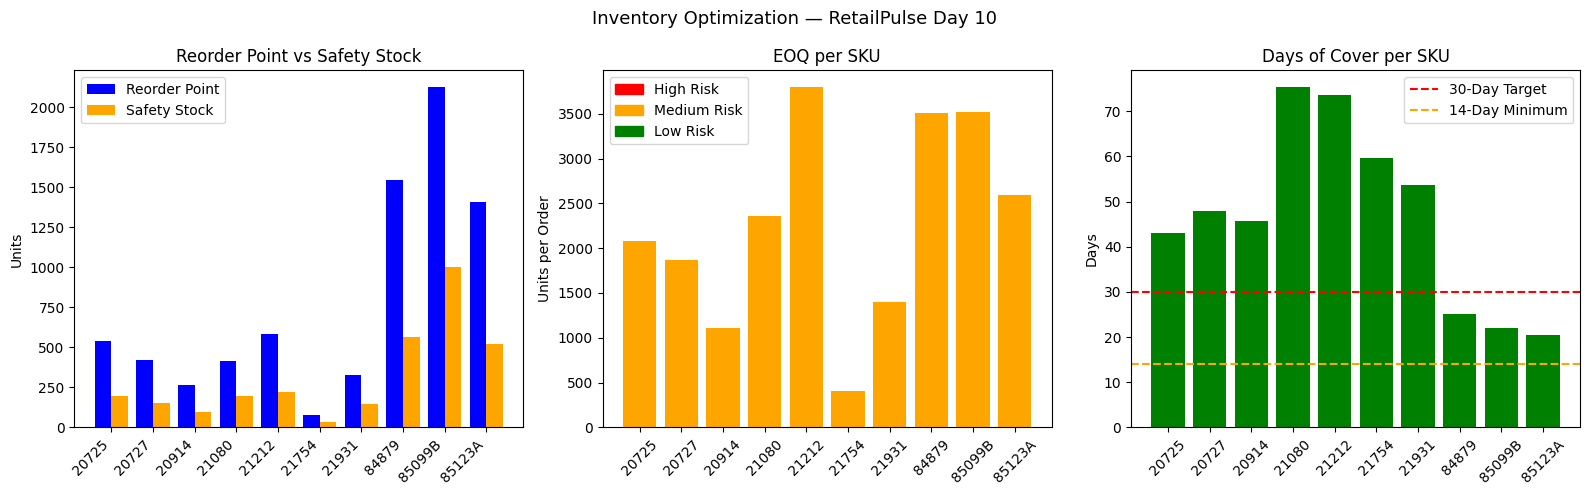

In [8]:
from matplotlib.patches import Patch

fig,axes=plt.subplots(1,3,figsize=(16,5))

skus=inventory_df["StockCode"].astype(str)
colors={"High Risk":"red","Medium Risk":"orange","Low Risk":"green"}

# Reorder point vs safety stock
x=np.arange(len(skus))

axes[0].bar(x,inventory_df["reorder_point"],width=0.4,label="Reorder Point",color="blue")
axes[0].bar(x+0.4,inventory_df["safety_stock"],width=0.4,label="Safety Stock",color="orange")
axes[0].set_xticks(x+0.2)
axes[0].set_xticklabels(skus,rotation=45,ha="right")
axes[0].set_title("Reorder Point vs Safety Stock")
axes[0].set_ylabel("Units")
axes[0].legend()

# EOQ per SKU
axes[1].bar(skus,inventory_df["eoq"],color=inventory_df["stockout_risk"].map(colors))
axes[1].set_title("EOQ per SKU")
axes[1].set_ylabel("Units per Order")
axes[1].tick_params(axis="x",rotation=45)
axes[1].legend(handles=[Patch(color=color,label=risk) for risk,color in colors.items()])

# Days of cover
axes[2].bar(skus,inventory_df["days_of_cover"],color="green")
axes[2].axhline(30,color="red",linestyle="--",label="30-Day Target")
axes[2].axhline(14,color="orange",linestyle="--",label="14-Day Minimum")
axes[2].set_title("Days of Cover per SKU")
axes[2].set_ylabel("Days")
axes[2].tick_params(axis="x",rotation=45)
axes[2].legend()

plt.suptitle("Inventory Optimization — RetailPulse Day 10",fontsize=13)
plt.tight_layout()
plt.savefig(figure/"10-Inventory_Optimization.png",dpi=150,bbox_inches="tight")
plt.show()

In [ ]:
output_cols = [
    'StockCode', 'avg_daily_demand', 'demand_std', 'unit_price',
    'safety_stock', 'reorder_point', 'eoq', 'max_stock',
    'days_of_cover', 'cv', 'stockout_risk',
    'current_stock_est', 'needs_reorder', 'reorder_qty'
]
final_df = inventory_df[output_cols].round(2)
final_df.to_csv(report / '10-Inventory_Optimization.csv', index=False)

print('Saved to 10-Inventory_Optimization.csv')
print()
print('========== SUMMARY ==========')
print(f'Total SKUs analysed  : {len(final_df)}')
print(f'SKUs needing reorder : {final_df["needs_reorder"].sum()}')
print(f'High risk SKUs       : {(final_df["stockout_risk"] == "High Risk").sum()}')
print(f'Avg days of cover    : {round(final_df["days_of_cover"].mean(), 1)}')
print(f'Avg EOQ              : {round(final_df["eoq"].mean(), 0)} units')
print('=============================')
print()
final_df

Saved to 10-Inventory_Optimization.csv

========== SUMMARY ==========
Total SKUs analysed  : 10
SKUs needing reorder : 0
High risk SKUs       : 0
Avg days of cover    : 46.6
Avg EOQ              : 2265.0 units



,StockCode,avg_daily_demand,demand_std,unit_price,safety_stock,reorder_point,eoq,max_stock,days_of_cover,cv,stockout_risk,current_stock_est,needs_reorder,reorder_qty
0,20725,48.43,45.53,1.63,198,537,2085,2622,43.0,0.94,Medium Risk,678,0,0
1,20727,38.87,34.40,1.63,150,422,1866,2288,48.0,0.88,Medium Risk,544,0,0
2,20914,24.33,21.88,2.88,95,265,1111,1376,45.7,0.90,Medium Risk,341,0,0
3,21080,31.30,44.71,0.82,195,414,2357,2771,75.3,1.43,Medium Risk,438,0,0
4,21212,51.53,51.18,0.52,223,584,3795,4379,73.6,0.99,Medium Risk,721,0,0
5,21754,6.87,7.25,5.96,32,80,410,490,59.7,1.06,Medium Risk,96,0,0
6,21931,26.10,33.51,1.95,146,329,1400,1729,53.6,1.28,Medium Risk,365,0,0
7,84879,140.17,129.56,1.66,564,1545,3513,5058,25.1,0.92,Medium Risk,1962,0,0
8,85099B,160.07,230.38,1.89,1003,2123,3519,5642,22.0,1.44,Medium Risk,2241,0,0
9,85123A,126.87,119.70,2.76,521,1409,2591,4000,20.4,0.94,Medium Risk,1776,0,0


In [ ]:
sim_df = product_df.sort_values(["StockCode","Date"]).copy()

avg = sim_df.groupby("StockCode")["units_sold"].transform(lambda x:x.shift(1).rolling(30,min_periods=1).mean()).fillna(0)
std = sim_df.groupby("StockCode")["units_sold"].transform(lambda x:x.shift(1).rolling(30,min_periods=1).std()).fillna(0)

demand = sim_df["units_sold"]

baseline_stock = (avg*14).round()

# z_score : extra backup stock
# Supplier takes 7 days to deliver new stock = Lead time 
#Safety Stock = Z-score × Demand Variation × √Lead Time
optimized_stock = (avg*14+1.28*std*np.sqrt(7)).round() # Z-score = 1.28 / Lead time = 7 days

baseline_under = (demand-baseline_stock).clip(lower=0).sum()
optimized_under = (demand-optimized_stock).clip(lower=0).sum()

baseline_over = (baseline_stock-demand).clip(lower=0).sum()
optimized_over = (optimized_stock-demand).clip(lower=0).sum()

understock_reduction = (baseline_under-optimized_under)/baseline_under*100
overstock_reduction = (baseline_over-optimized_over)/baseline_over*100

print("Estimated understock reduction:",round(understock_reduction,2),"%")
print("Estimated overstock reduction:",round(overstock_reduction,2),"%")

Estimated understock reduction: 25.9 %
Estimated overstock reduction: -35.59 %


## Inventory Policy Selection

The best balanced inventory policy uses a `14-day` review period and a `1.28` safety-stock z-score.

This policy reduces estimated understock by `25.90%`, meeting the minimum target of `25%`.

However, estimated overstock increases by `35.59%` because additional safety stock is maintained to prevent stock shortages.

This shows a practical trade-off between reducing stockouts and holding extra inventory.